# Support Vector Machine (SVM)

## Learning Notes & Practical Implementation

Support Vector Machines (SVMs) are supervised machine learning algorithms used mainly for **classification**, but they can also be used for regression.

The core idea is to find a decision boundary (hyperplane) that separates classes while maximizing the **margin** between the classes.

### What I should understand

- Hyperplanes
- Margins
- Support vectors
- Hard margin vs soft margin
- The `C` hyperparameter
- Feature scaling
- Linear SVM
- Kernel trick
- RBF kernel
- `gamma`
- Overfitting and underfitting
- SVM advantages and disadvantages


## 1. Intuition

Imagine two classes of points on a graph.

An SVM tries to find a boundary that separates the classes.

There may be many possible boundaries, but SVM prefers the one with the **largest margin**.

The margin is the distance between the decision boundary and the closest training samples from each class.

The closest samples are called **support vectors**.

> **Main idea:** SVM chooses the decision boundary that maximizes the margin while controlling classification errors.


## 2. Hyperplane

For two features, the decision boundary can be represented as a line:

$$
w_1x_1 + w_2x_2 + b = 0
$$

For higher-dimensional data, this becomes a **hyperplane**.

- `w` = model weights
- `x` = feature values
- `b` = bias/intercept

The prediction depends on which side of the hyperplane a sample falls on.


## 3. Margin

The **margin** is the distance between the decision boundary and the closest samples.

A larger margin generally gives better generalization.

SVM tries to maximize this margin.

Conceptually:

```text
Class 0       Support Vector
   ●                 ●
    ●              /
      ●          /      ← margin
        ●      /
----------|----------------  Decision boundary
        /|
      /  |
    /    |
  ●      ●
Class 1       Support Vector
```

The exact geometry becomes more important when studying the optimization problem, but the key intuition is:

> Find a boundary that separates the classes with the largest possible margin.


## 4. Support Vectors

**Support vectors** are the training samples closest to the decision boundary.

They are especially important because they determine the position of the optimal boundary.

If some samples far away from the boundary are removed, the boundary may not change much.

Changing or removing important support vectors can change the boundary significantly.


## 5. Hard Margin vs Soft Margin

### Hard Margin

A hard-margin SVM requires the classes to be perfectly separable.

This works only when the data can be separated without errors.

It is also very sensitive to outliers.

### Soft Margin

Real-world datasets are rarely perfectly separable.

A soft-margin SVM allows some samples to violate the margin or even be misclassified.

The `C` hyperparameter controls the trade-off between:

- maximizing the margin
- minimizing training errors


## 6. The `C` Hyperparameter

`C` controls how strongly the model penalizes classification errors.

### Small `C`

The model allows more violations of the margin.

- Wider margin
- More tolerance for training errors
- Stronger regularization
- Can reduce overfitting

### Large `C`

The model penalizes errors more strongly.

- Narrower margin
- Fewer training errors
- Less regularization
- Can overfit

There is no universally best value. It should be selected using validation or cross-validation.


## 7. Why Feature Scaling Matters

SVM is sensitive to feature scale because distances and geometric relationships are important.

For example:

```text
Age:       18 → 80
Income:    1,000 → 100,000
```

The larger numerical scale of Income could dominate the geometry.

Therefore, standardization is usually recommended before training an SVM.

A common choice is:

```python
from sklearn.preprocessing import StandardScaler
```

and:

```python
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
```

> Fit the scaler only on the training data, then transform the test data with the same scaler.


## 8. Linear SVM

If the classes can be separated reasonably well with a straight boundary, a **linear SVM** can be used.

In Scikit-Learn:

```python
from sklearn.svm import SVC

model = SVC(kernel="linear")
```

The model learns a linear decision boundary.


## 9. When a Linear Boundary Is Not Enough

Some datasets cannot be separated well with a straight line.

For example, imagine one class is inside a circle and another class surrounds it.

A linear boundary cannot separate them effectively.

SVM can solve some non-linear problems using **kernels**.


## 10. Kernel Trick

A kernel allows SVM to model non-linear relationships without explicitly creating all the higher-dimensional features.

Common kernels include:

- `linear`
- `poly`
- `rbf`
- `sigmoid`

The **RBF (Radial Basis Function) kernel** is a common choice for non-linear problems.

```python
model = SVC(kernel="rbf")
```

The kernel trick is one of the most important ideas behind non-linear SVMs.


## 11. The `gamma` Hyperparameter

For the RBF kernel, `gamma` controls how far the influence of an individual training sample reaches.

### Small `gamma`

Each sample has a broader influence.

- Smoother decision boundary
- Simpler model
- Can underfit if too small

### Large `gamma`

Each sample has a more local influence.

- More complex decision boundary
- Can fit training data very closely
- Can overfit if too large

`gamma` and `C` often need to be tuned together.


## 12. Practical Workflow

A typical SVM classification workflow is:

```text
Load dataset
      ↓
Explore data
      ↓
Separate X and y
      ↓
Train/Test Split
      ↓
Scale features
      ↓
Train SVM
      ↓
Predict
      ↓
Evaluate
      ↓
Tune C / gamma / kernel
      ↓
Cross-validation
```


# 13. Practical Implementation

We will use the Breast Cancer dataset for a classification example.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
    classification_report
)


In [2]:
data = load_breast_cancer(as_frame=True)

df = data.frame

df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [4]:
df["target"].value_counts()


target
1    357
0    212
Name: count, dtype: int64

## 14. Separate Features and Target

In [5]:
X = df.drop("target", axis=1)
y = df["target"]


## 15. Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## 16. Feature Scaling

SVM is sensitive to feature scale, so we standardize the features.

Important:

- `fit_transform()` on training data
- `transform()` on test data

This prevents information from the test set from influencing the scaler.


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 17. Train a Linear SVM

In [8]:
linear_svm = SVC(
    kernel="linear",
    C=1.0
)

linear_svm.fit(X_train_scaled, y_train)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [9]:
y_pred = linear_svm.predict(X_test_scaled)


In [10]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


Accuracy : 0.9737
Precision: 0.9859
Recall   : 0.9722
F1 Score : 0.9790


In [11]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## 18. Confusion Matrix

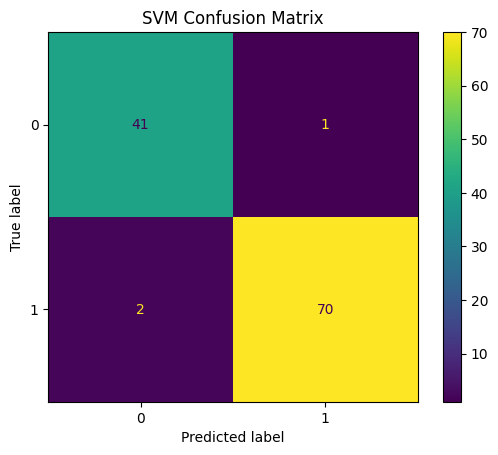

In [12]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("SVM Confusion Matrix")
plt.show()


## 19. RBF SVM

Now we can try a non-linear SVM using the RBF kernel.

```python
SVC(kernel="rbf")
```

The main hyperparameters to experiment with are:

- `C`
- `gamma`


In [13]:
rbf_svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

rbf_svm.fit(X_train_scaled, y_train)

rbf_pred = rbf_svm.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, rbf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rbf_pred):.4f}")
print(f"Recall: {recall_score(y_test, rbf_pred):.4f}")
print(f"F1: {f1_score(y_test, rbf_pred):.4f}")


Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1: 0.9861


## 20. Experiment with `C`

In [14]:
for C in [0.01, 0.1, 1, 10, 100]:
    model = SVC(
        kernel="rbf",
        C=C,
        gamma="scale"
    )

    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)

    score = accuracy_score(y_test, predictions)

    print(f"C={C:<6} Accuracy={score:.4f}")


C=0.01   Accuracy=0.6316
C=0.1    Accuracy=0.9474
C=1      Accuracy=0.9825
C=10     Accuracy=0.9737
C=100    Accuracy=0.9474


## 21. Experiment with `gamma`

In [15]:
for gamma in ["scale", "auto", 0.001, 0.01, 0.1, 1]:
    model = SVC(
        kernel="rbf",
        C=1.0,
        gamma=gamma
    )

    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)

    score = accuracy_score(y_test, predictions)

    print(f"gamma={str(gamma):<8} Accuracy={score:.4f}")


gamma=scale    Accuracy=0.9825
gamma=auto     Accuracy=0.9825
gamma=0.001    Accuracy=0.9561
gamma=0.01     Accuracy=0.9825
gamma=0.1      Accuracy=0.9561
gamma=1        Accuracy=0.6316


## 22. Important Experiment

Do not simply choose the model with the highest test-set score after trying many values.

The proper next step is **cross-validation** and hyperparameter tuning.

For example, later we can use:

```python
GridSearchCV
RandomizedSearchCV
```

to find good values of `C`, `gamma`, and `kernel` using training data and cross-validation.


## 23. SVM vs Other Models

After learning several classification algorithms, compare them on the same dataset.

Example:

| Model | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|
| Logistic Regression | ... | ... | ... | ... |
| Decision Tree | ... | ... | ... | ... |
| Random Forest | ... | ... | ... | ... |
| KNN | ... | ... | ... | ... |
| SVM | ... | ... | ... | ... |

The goal is not simply to find the highest number.

Also consider:

- Training time
- Prediction time
- Interpretability
- Data preprocessing requirements
- Model complexity
- Generalization


# 24. Advantages of SVM

- Effective in high-dimensional feature spaces.
- Can model linear and non-linear decision boundaries.
- The kernel trick makes non-linear classification possible.
- Often performs well when the classes have a clear margin.
- Works well with properly scaled numerical features.

# 25. Disadvantages of SVM

- Feature scaling is usually important.
- Choosing `C`, `gamma`, and the kernel can require experimentation.
- Training can become expensive on very large datasets.
- Non-linear SVMs can be harder to interpret.
- It is less convenient when the dataset contains many millions of samples.

# 26. Final Summary

SVM tries to find a decision boundary with a large margin between classes.

The closest samples to the boundary are the **support vectors**.

`C` controls the trade-off between a wide margin and training errors.

For non-linear problems, SVM can use kernels such as the **RBF kernel**.

For RBF SVM:

- `C` controls regularization / error penalty.
- `gamma` controls how local the influence of training samples is.

Because SVM relies on geometry and distances, **feature scaling is usually essential**.

The main concepts I should remember are:

```text
Hyperplane
    ↓
Margin
    ↓
Support Vectors
    ↓
Soft Margin
    ↓
C
    ↓
Feature Scaling
    ↓
Kernel Trick
    ↓
RBF Kernel
    ↓
Gamma
```
